In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loadiung cleaned dataset
air_df = pd.read_csv("../data/processed/air_quality_cleaned.csv")

In [3]:
air_df.head()

,air_id,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,1,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",2026-03-03 15:00:00,26.088131,87.938403,CO,17.0,22.0,21.0
1,2,India,Bihar,Motihari,"Gandak Colony, Motihari - BSPCB",2026-03-03 15:00:00,26.630860,84.900510,NO2,8.0,10.0,9.0
2,3,India,Bihar,Motihari,"Gandak Colony, Motihari - BSPCB",2026-03-03 15:00:00,26.630860,84.900510,SO2,3.0,3.0,3.0
3,4,India,Bihar,Motihari,"Gandak Colony, Motihari - BSPCB",2026-03-03 15:00:00,26.630860,84.900510,CO,36.0,46.0,40.0
4,5,India,Bihar,Motihari,"Gandak Colony, Motihari - BSPCB",2026-03-03 15:00:00,26.630860,84.900510,OZONE,3.0,5.0,4.0


In [18]:
air_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3329 entries, 0 to 3328
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   air_id         3329 non-null   int64         
 1   country        3329 non-null   object        
 2   state          3329 non-null   object        
 3   city           3329 non-null   object        
 4   station        3329 non-null   object        
 5   last_update    3329 non-null   datetime64[ns]
 6   latitude       3329 non-null   float64       
 7   longitude      3329 non-null   float64       
 8   pollutant_id   3329 non-null   object        
 9   pollutant_min  3195 non-null   float64       
 10  pollutant_max  3195 non-null   float64       
 11  pollutant_avg  3195 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(5)
memory usage: 312.2+ KB


In [5]:
air_df.describe()

,air_id,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3329.00000,3329.000000,3329.000000,3195.000000,3195.000000,3195.000000
mean,1665.00000,23.309351,78.595090,28.194992,95.054147,54.723005
std,961.14385,5.071971,4.914670,31.950795,99.298276,55.009517
min,1.00000,8.514909,70.776774,1.000000,1.000000,1.000000
25%,833.00000,19.235581,75.387310,6.000000,20.000000,14.000000
50%,1665.00000,23.817487,77.287209,16.000000,64.000000,35.000000
75%,2497.00000,27.608912,80.891736,39.000000,124.000000,80.000000
max,3329.00000,34.066206,94.636574,257.000000,500.000000,393.000000


In [17]:
air_df['last_update'] = pd.to_datetime(
    air_df['last_update'],
    dayfirst=True,
    errors='coerce'
)

## Pollutant Type Distribution

In [6]:
air_df['pollutant_id'].value_counts()

pollutant_id
PM2.5    494
NO2      489
PM10     488
CO       481
OZONE    476
SO2      471
NH3      430
Name: count, dtype: int64

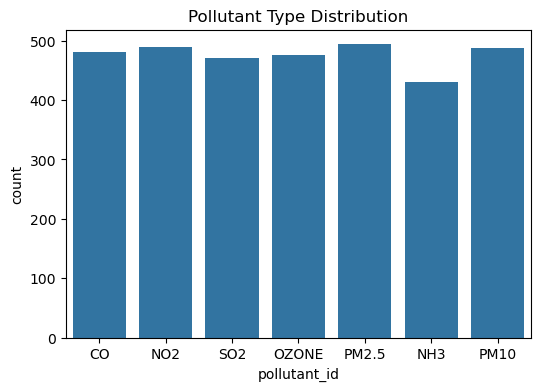

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=air_df, x='pollutant_id')
plt.title("Pollutant Type Distribution")
plt.show()

## City Distribution

In [8]:
air_df['city'].value_counts().head(10)

city
Delhi        298
Mumbai       175
Hyderabad     88
Bengaluru     67
Pune          55
Ahmedabad     55
Kolkata       49
Chennai       45
Jaipur        42
Lucknow       41
Name: count, dtype: int64

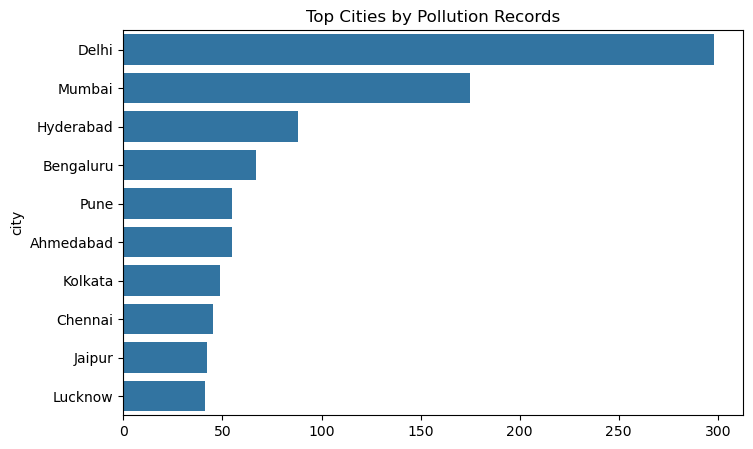

In [9]:
top_cities = air_df['city'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top Cities by Pollution Records")
plt.show()

## State Distribution

In [10]:
air_df['state'].value_counts().head(10)

state
Maharashtra       578
Uttar_Pradesh     368
Rajasthan         322
Delhi             298
Bihar             231
Haryana           196
Madhya Pradesh    169
West_Bengal       154
Karnataka         153
Gujarat           135
Name: count, dtype: int64

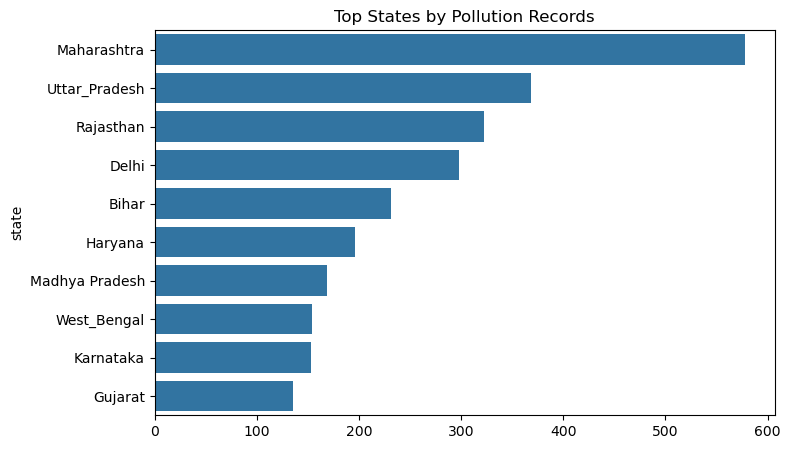

In [11]:
top_states = air_df['state'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top States by Pollution Records")
plt.show()

## Pollutant Average Level Distribution

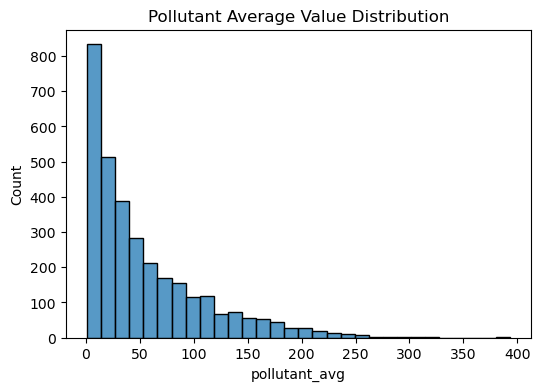

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(air_df['pollutant_avg'], bins=30)
plt.title("Pollutant Average Value Distribution")
plt.show()

## Pollutant Average by Type

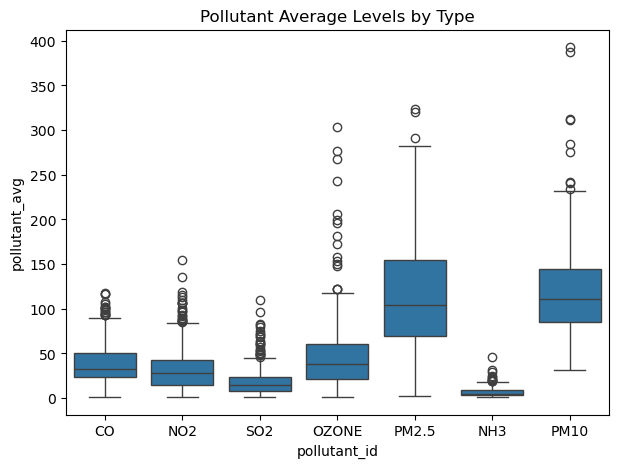

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(data=air_df, x='pollutant_id', y='pollutant_avg')
plt.title("Pollutant Average Levels by Type")
plt.show()

## Pollutant Monitoring Stations

In [14]:
air_df['station'].nunique()

499

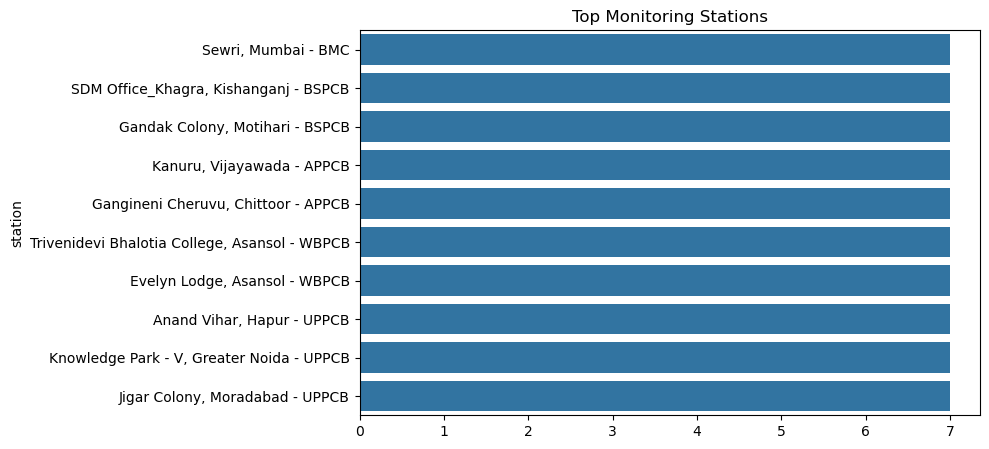

In [15]:
top_stations = air_df['station'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_stations.values, y=top_stations.index)
plt.title("Top Monitoring Stations")
plt.show()

## Average Pollution by Pollutant

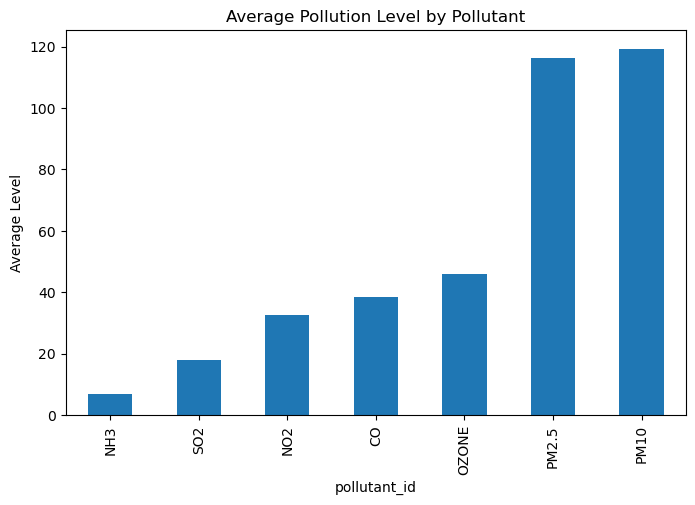

In [32]:
pollutant_avg = air_df.groupby('pollutant_id')['pollutant_avg'].mean()

plt.figure(figsize=(8,5))
pollutant_avg.sort_values().plot(kind='bar')
plt.title("Average Pollution Level by Pollutant")
plt.ylabel("Average Level")
plt.show()

## Most Polluted Cities

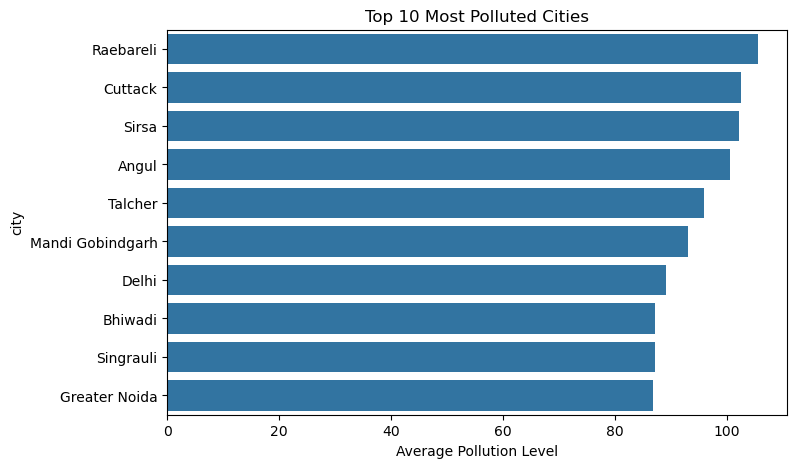

In [33]:
city_pollution = air_df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=city_pollution.values, y=city_pollution.index)
plt.title("Top 10 Most Polluted Cities")
plt.xlabel("Average Pollution Level")
plt.show()

## Pollution by State

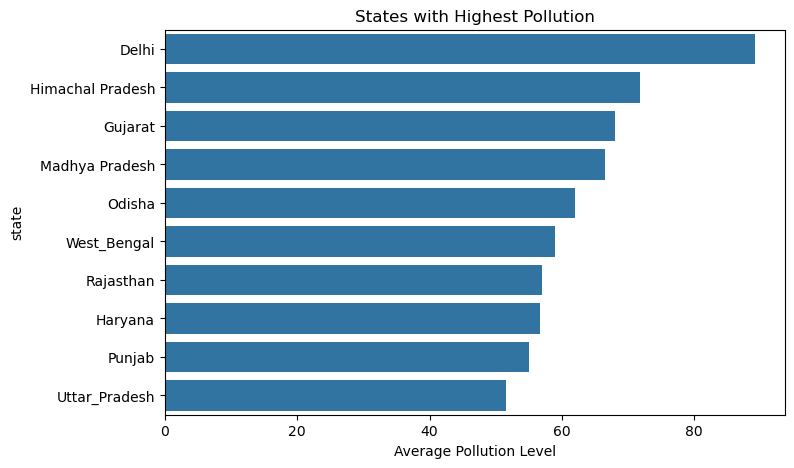

In [34]:
state_pollution = air_df.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=state_pollution.values, y=state_pollution.index)
plt.title("States with Highest Pollution")
plt.xlabel("Average Pollution Level")
plt.show()